# <b><div style='padding:8px;background-color:#003f88;color:white;border-radius:2px;font-size:100%;text-align: left'>Trial Activation</div></b>

 ## **Project Overview**

Splendor Analytics runs a 30-day free trial for new organisations signing up to its workforce management platform — a product covering shift scheduling, time tracking, payroll approvals, and team communications. The core problem: the product team has no definition of what a "good" trial looks like. While roughly 1 in 5 trialists eventually converts to a paying customer, the team cannot identify who is on track to convert, when to intervene, or which in-app behaviours actually drive the decision. Without that clarity, every onboarding improvement is a guess.

This project solves that by:

1. Defining "Trial Activation" — a specific set of in-app behaviours that signal a trialist has genuinely experienced the platform's core value.
2. Building the data infrastructure to track activation at scale using SQL mart models in a data warehouse layer.
3. Running descriptive analysis to surface actionable insights that inform the product team's onboarding decisions.

 ## **Project Objectives**

1. **Data Cleaning & Exploration (Task 1)**
- Load and clean the raw behavioural event dataset
- Remove duplicate records and validate data integrity
- Conduct exploratory data analysis (EDA) to understand engagement patterns across converted and non-converted orgs
- Identify which activities are indicative of conversion using multiple analytical methods: point-biserial correlation, chi-squared tests, Random Forest feature importance, and engagement segmentation

2. **Trial Goal Definition (Task 1 continued)**
- Define "Trial Activation" as a set of measurable in-app behaviours grounded in product-value logic and supported by analytical evidence
- Define 5 specific trial goals with clear thresholds:
Goal 1 — Core Scheduling      : ≥3 shifts created
Goal 2 — Schedule Visibility  : ≥3 schedule views
Goal 3 — Time Tracking        : ≥1 punch-in event
Goal 4 — Payroll Approval     : ≥1 shift approved
Goal 5 — Team Communications  : ≥1 team message sent
• An organisation achieves Trial Activation when all 5 goals are completed within the 30-day trial window

3. **SQL Data Modelling (Task 2)**
- Build a marts-layer data warehouse using plain PostgreSQL:
    - mart_trial_goals      — one row per org, 5 boolean goal flags
    - mart_trial_activation — one row per org, full activation status, bottleneck diagnosis, and funnel stage
- Staging layer built on stg_events_clean.csv via:
    - stg_events_raw            — raw cleaned data loaded into Postgres
    - stg_events                — view adding days_to_convert + module_name
    - int_org_activity_counts   — pre-aggregated per org × activity

4. **Descriptive Analytics & Product Metrics (Task 3)**
- Compute key product metrics:
    - Overall conversion rate and monthly cohort breakdown
    - Trial activation rate and goal-by-goal completion rates
    - Module adoption rates across all 5 product modules
    - Time-to-convert distribution
    - Daily engagement volume over the 30-day trial
    - Sequential activation funnel and drop-off rates
    - Feature engagement depth per activity
    - Weekly retention proxy
- Generate visualisations to communicate findings clearly
- Provide actionable recommendations for the product team

## **Dataset**

* `Source`      : DA_task.csv — raw behavioural event log
* `Clean source`: stg_events_clean.csv — deduplicated output of Task 1
* `Period`      : January – March (trial start dates)
* `Raw rows`    : 170,526 events across 966 trialling organisations
* `Clean rows`  : 102,895 events (67,631 exact duplicates removed)
* `Organisations`: 966 total | 206 converted (21.3%) | 760 did not convert
* `Activities`  : 28 unique in-app activity types across 5 product modules:
    - Scheduling, Time & Attendance, Absence Management,
    - Payroll & Finance, and Communications

## **Task 1: Data Cleaning & Exploration and Trial Goal Definition**

In [1]:
# Import required Libraries

import pandas as pd
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

# Consistent style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
COLORS = {'converted': '#2ecc71', 'not_converted': '#e74c3c', 'neutral': '#3498db', 'highlight': '#f39c12',}

%matplotlib inline

In [2]:
# Load the dataset

df = pd.read_csv(r"C:\Users\Harrison\Desktop\trial_activation\data\DA task.csv")

df.head()

,ORGANIZATION_ID,ACTIVITY_NAME,TIMESTAMP,CONVERTED,CONVERTED_AT,TRIAL_START,TRIAL_END
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
3,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:05:18.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
4,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:06:00.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000


## **Data Cleaning & Exploration (Task 1)**

The raw dataset (DA_task.csv) contains 170,526 behavioural events across
966 trialling organisations recorded between January and March.
Before any analysis can begin, the data must be validated and cleaned.

In this step we:
- Load the raw CSV and inspect its structure, column types, and shape
- Parse all datetime columns (TIMESTAMP, TRIAL_START, TRIAL_END,
  CONVERTED_AT) from string into proper datetime objects
- Audit every column for null values — CONVERTED_AT is expected to be
  null for non-converted organisations, all other columns must be complete
- Detect and remove 67,631 exact duplicate rows (identical organisation,
  activity, and timestamp triplets that carry no additional signal)
- Validate data consistency — every organisation marked CONVERTED=True
  must have a corresponding CONVERTED_AT timestamp
- Derive trial-context fields: days_into_trial, trial_length_days,
  and event_within_trial to support downstream analysis
- Export the cleaned dataset as stg_events_clean.csv for use in
  Task 2 (SQL models) and Task 3 (descriptive analytics)

In [3]:
# Parse datetimes 

datetime_cols = ['TIMESTAMP', 'TRIAL_START', 'TRIAL_END', 'CONVERTED_AT']
for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [4]:
# Check missing values 

nulls = df.isnull().sum()
for col, n in nulls.items():
    pct = n / len(df) * 100
    note = "  ← expected: non-converters have no conversion timestamp" if col == 'CONVERTED_AT' and n > 0 else ""
    print(f"  {col:<25} {n:>7,} nulls ({pct:5.1f}%){note}")

  ORGANIZATION_ID                 0 nulls (  0.0%)
  ACTIVITY_NAME                   0 nulls (  0.0%)
  TIMESTAMP                       0 nulls (  0.0%)
  CONVERTED                       0 nulls (  0.0%)
  CONVERTED_AT              136,291 nulls ( 79.9%)  ← expected: non-converters have no conversion timestamp
  TRIAL_START                     0 nulls (  0.0%)
  TRIAL_END                       0 nulls (  0.0%)


136, 291 (79.9%) missing  is expected because non-converts have no timmestamp

In [5]:
# Check duplicate

n_dupes = df.duplicated().sum()
print(f"{n_dupes:,} exact duplicate rows detected "
      f"({n_dupes/len(df)*100:.1f}% of raw data)")
print("     We will drop exact duplicates — identical org + activity + timestamp because they carry no additional signal")

df = df.drop_duplicates().copy()
print(f"     Clean shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

67,631 exact duplicate rows detected (39.7% of raw data)
     We will drop exact duplicates — identical org + activity + timestamp because they carry no additional signal
     Clean shape: 102,895 rows × 7 columns


In [6]:
# CONVERTED_AT consistency check

# Every converted org should have a CONVERTED_AT
converted_no_ts = df[(df['CONVERTED'] == True) & (df['CONVERTED_AT'].isna())]
print(f"CONVERTED=True but no CONVERTED_AT: {converted_no_ts.shape[0]:,} rows (should be 0)")

not_conv_with_ts = df[(df['CONVERTED'] == False) & (df['CONVERTED_AT'].notna())]
print(f"     CONVERTED=False but has CONVERTED_AT : {not_conv_with_ts.shape[0]:,} rows (should be 0)")

CONVERTED=True but no CONVERTED_AT: 0 rows (should be 0)
     CONVERTED=False but has CONVERTED_AT : 0 rows (should be 0)


In [7]:
# Derive useful fields

df['days_into_trial'] = (df['TIMESTAMP'] - df['TRIAL_START']).dt.total_seconds() / 86400
df['trial_length_days'] = (df['TRIAL_END'] - df['TRIAL_START']).dt.days
df['event_within_trial'] = (df['days_into_trial'] >= 0) & (df['days_into_trial'] <= df['trial_length_days'])

out_of_trial = (~df['event_within_trial']).sum()
print(f"Events outside 30-day trial window: {out_of_trial:,} "
      f"({out_of_trial/len(df)*100:.1f}%) — retained for completeness")

print(f"Cleaned dataset: {df.shape[0]:,} rows, {df['ORGANIZATION_ID'].nunique():,} unique organisations")

Events outside 30-day trial window: 0 (0.0%) — retained for completeness
Cleaned dataset: 102,895 rows, 966 unique organisations


## **Organization-Level Feature Matrix**

The raw event log is at the event grain — one row per activity per org. To analyse conversion behaviour, we need to reshape this into an
organisation-level feature matrix — one row per organisation — where
each column represents a measurable behavioural attribute of that org.

In this step we:
- Aggregate the cleaned event log to the organisation level using
  groupby, computing: total events, unique activity types used,
  first and last event timestamps, and trial active days
- Pivot activity counts so each of the 28 unique activities becomes
  its own column, showing how many times each org performed it
- Derive org-level metadata: days_to_convert (for converted orgs),
  trial_active_days (span between first and last event), and
  engagement tier (based on number of unique activities used)
- Merge the activity pivot with org metadata into a single flat
  feature matrix of 966 rows × 34 columns — one row per organisation
- This matrix becomes the input for all conversion driver analysis
  and trial goal evaluation in subsequent steps

In [8]:
# Per-org metadata

org_meta = df.groupby('ORGANIZATION_ID').agg(
    converted      = ('CONVERTED', 'first'),
    trial_start    = ('TRIAL_START', 'first'),
    trial_end      = ('TRIAL_END', 'first'),
    converted_at   = ('CONVERTED_AT', 'first'),
    total_events   = ('ACTIVITY_NAME', 'count'),
    unique_acts    = ('ACTIVITY_NAME', 'nunique'),
    first_event_ts = ('TIMESTAMP', 'min'),
    last_event_ts  = ('TIMESTAMP', 'max'),
).reset_index()

org_meta['days_to_convert'] = (org_meta['converted_at'] - org_meta['trial_start']).dt.days
org_meta['trial_active_days'] = (org_meta['last_event_ts'] - org_meta['first_event_ts']).dt.days.clip(lower=0)


In [9]:
# Per-org activity counts (pivot)

act_pivot = df.groupby(['ORGANIZATION_ID', 'ACTIVITY_NAME']).size().unstack(fill_value=0).reset_index()
act_pivot.columns.name = None

org_df = org_meta.merge(act_pivot, on='ORGANIZATION_ID', how='left')

In [10]:
# Activity columns (all except the metadata)

META_COLS = ['ORGANIZATION_ID','converted','trial_start','trial_end','converted_at',
             'total_events','unique_acts','first_event_ts','last_event_ts',
             'days_to_convert','trial_active_days']
ACTIVITY_COLS = [c for c in org_df.columns if c not in META_COLS]

n_converted = org_df['converted'].sum()
n_total = len(org_df)
conv_rate = n_converted / n_total
print(f"  Organisations total   : {n_total:,}")
print(f"  Converted to paid     : {n_converted:,}  ({conv_rate:.1%})")
print(f"  Did not convert       : {n_total - n_converted:,}  ({1-conv_rate:.1%})")
print(f"  Unique activities     : {len(ACTIVITY_COLS)}")


  Organisations total   : 966
  Converted to paid     : 206  (21.3%)
  Did not convert       : 760  (78.7%)
  Unique activities     : 28


## **Exploratory Data Analysis (EDA)**

Exploratory Data Analysis is a crucial step in any data analysis project.
As part of our EDA, we dive into the data and visualise it to uncover
patterns, distributions, and relationships before applying formal methods.

### What is the Overall Conversion Rate?

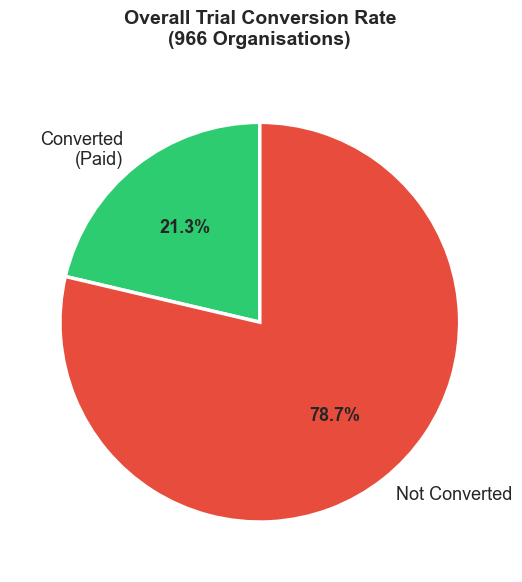

In [11]:
# Conversion Rate

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    [n_converted, n_total - n_converted],
    labels=['Converted\n(Paid)', 'Not Converted'],
    colors=[COLORS['converted'], COLORS['not_converted']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
    textprops={'fontsize': 13}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(13)
ax.set_title('Overall Trial Conversion Rate\n(966 Organisations)',
             fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

>**The pie chart**
shows the split between converted (21.3%) and non-converted (78.7%)
organisations — establishing the baseline conversion rate that all
subsequent analysis is measured against.

### How is Engagement Distributed?

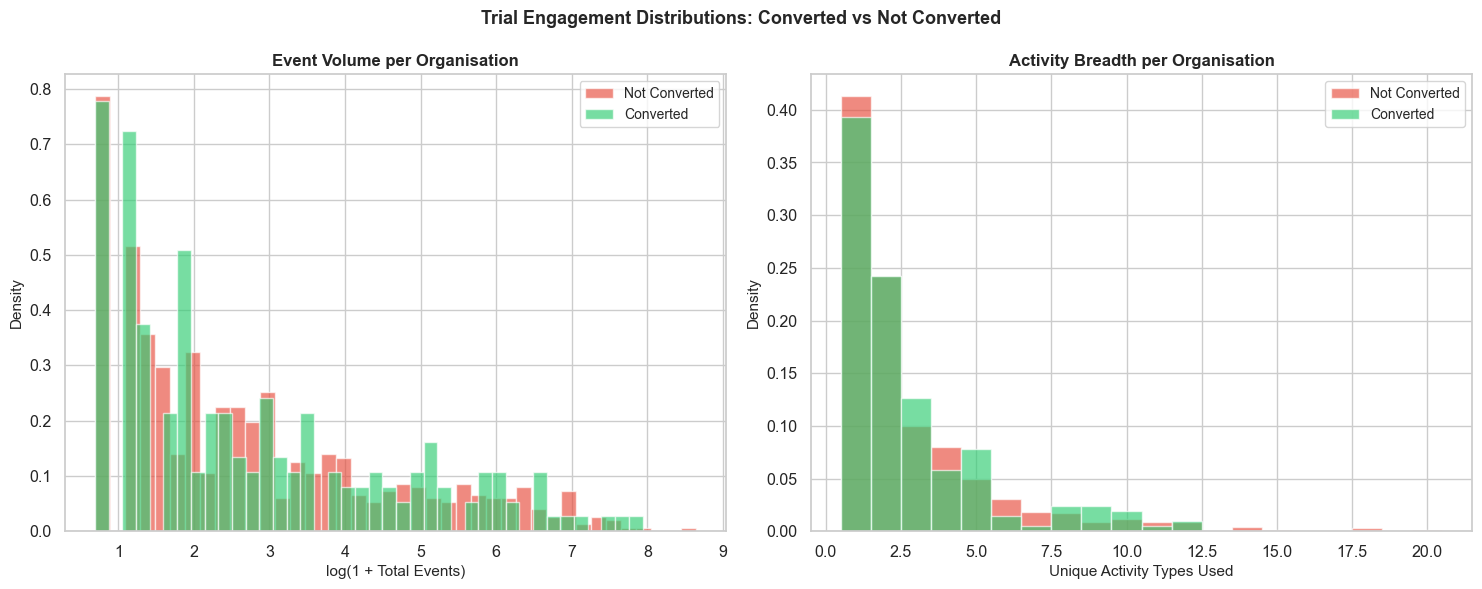

In [12]:
# Engagement Distributions

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Trial Engagement Distributions: Converted vs Not Converted',
             fontweight='bold', fontsize=13)

# Event volume
ax = axes[0]
ax.hist(np.log1p(org_df.loc[~org_df['converted'], 'total_events']),
        bins=40, alpha=0.65, color=COLORS['not_converted'],
        label='Not Converted', density=True)
ax.hist(np.log1p(org_df.loc[ org_df['converted'], 'total_events']),
        bins=40, alpha=0.65, color=COLORS['converted'],
        label='Converted', density=True)
ax.set_xlabel('log(1 + Total Events)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Event Volume per Organisation', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)

# Activity breadth
ax = axes[1]
ax.hist(org_df.loc[~org_df['converted'], 'unique_acts'],
        bins=range(1, 22), alpha=0.65, color=COLORS['not_converted'],
        label='Not Converted', align='left', density=True)
ax.hist(org_df.loc[ org_df['converted'], 'unique_acts'],
        bins=range(1, 22), alpha=0.65, color=COLORS['converted'],
        label='Converted', align='left', density=True)
ax.set_xlabel('Unique Activity Types Used', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Activity Breadth per Organisation', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

>**The Event Volume Distribution (Histogram)**
>Compares the distribution of total events per organisation between
converted and non-converted groups on a log scale, revealing whether
higher activity volume is associated with conversion.

>**The Activity Breadth per Organisation (Histogram)**
Compares the number of unique activity types used per org between
converted and non-converted groups, showing whether using more
features of the platform is linked to conversion.

### How is the Activity Adoption & Conversion Lift?

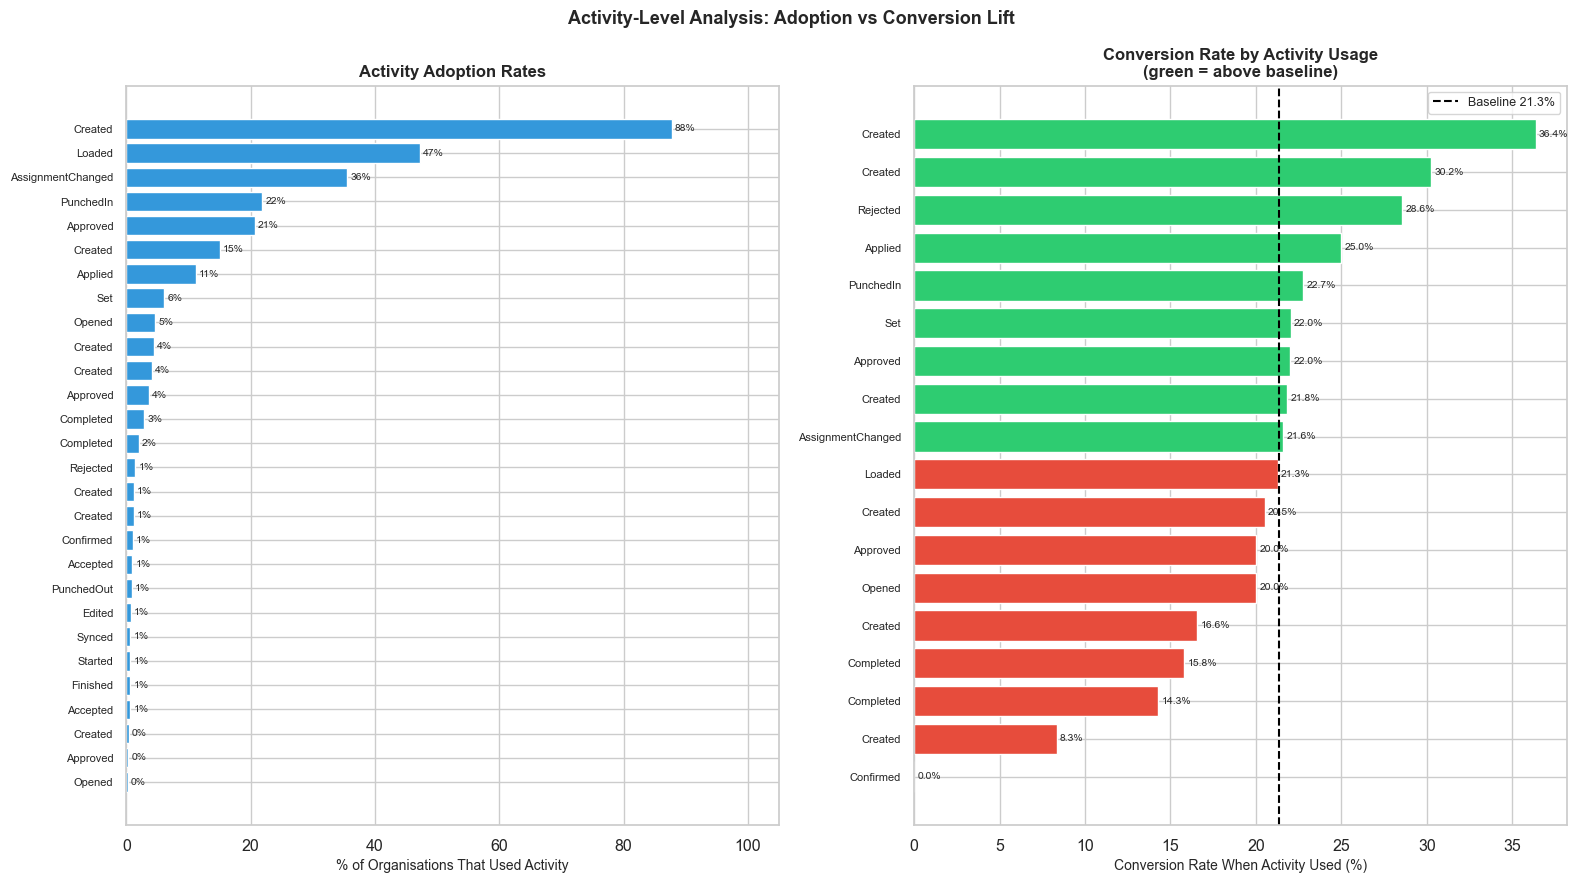

In [13]:
# Activity Adoption + Conversion Lift

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
fig.suptitle('Activity-Level Analysis: Adoption vs Conversion Lift',
             fontweight='bold', fontsize=13)

def short_name(a):
    return (a.replace('Scheduling.','S.').replace('PunchClock.','PC.')
             .replace('Communication.','Comm.').replace('Absence.','Abs.')
             .replace('Mobile.','Mob.').replace('Break.Activate.','Brk.')
             .replace('Timesheets.','TS.').split('.')[-1][:28])

# Adoption rates
ax = axes[0]
adopt_s = pd.Series(
    {act: (org_df[act] > 0).mean() for act in ACTIVITY_COLS}
).sort_values(ascending=True)
bars = ax.barh(range(len(adopt_s)), adopt_s.values * 100,
               color=COLORS['neutral'], edgecolor='white')
for bar, v in zip(bars, adopt_s.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{v:.0%}', va='center', fontsize=7.5)
ax.set_yticks(range(len(adopt_s)))
ax.set_yticklabels([short_name(a) for a in adopt_s.index], fontsize=8)
ax.set_xlabel('% of Organisations That Used Activity', fontsize=10)
ax.set_title('Activity Adoption Rates', fontweight='bold', fontsize=12)
ax.set_xlim(0, 105)

# Conversion rate by activity
ax = axes[1]
cr_s = pd.Series({
    act: org_df.loc[org_df[act] > 0, 'converted'].mean()
    for act in ACTIVITY_COLS if (org_df[act] > 0).sum() >= 10
}).sort_values(ascending=True)
bar_cols = [COLORS['converted'] if v > conv_rate else COLORS['not_converted']
            for v in cr_s.values]
bars2 = ax.barh(range(len(cr_s)), cr_s.values * 100,
                color=bar_cols, edgecolor='white')
for bar, v in zip(bars2, cr_s.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{v:.1%}', va='center', fontsize=7.5)
ax.axvline(conv_rate * 100, color='black', linestyle='--', linewidth=1.5,
           label=f'Baseline {conv_rate:.1%}')
ax.set_yticks(range(len(cr_s)))
ax.set_yticklabels([short_name(a) for a in cr_s.index], fontsize=8)
ax.set_xlabel('Conversion Rate When Activity Used (%)', fontsize=10)
ax.set_title('Conversion Rate by Activity Usage\n(green = above baseline)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

>**The Activity Adoption Rates (Horizontal Bar)**
Shows what percentage of organisations used each of the 28 activities,
revealing which features are widely adopted vs rarely discovered.
Scheduling.Shift.Created leads at 88%; most other activities are
used by fewer than 25% of organisations.

>**The Conversion Rate by Activity Usage (Horizontal Bar)**
For each activity used by at least 10 organisations, shows the
conversion rate among orgs that used it vs the 21.3% baseline,
highlighting which activities have above-baseline conversion lift.

### How long does it Take to Convert

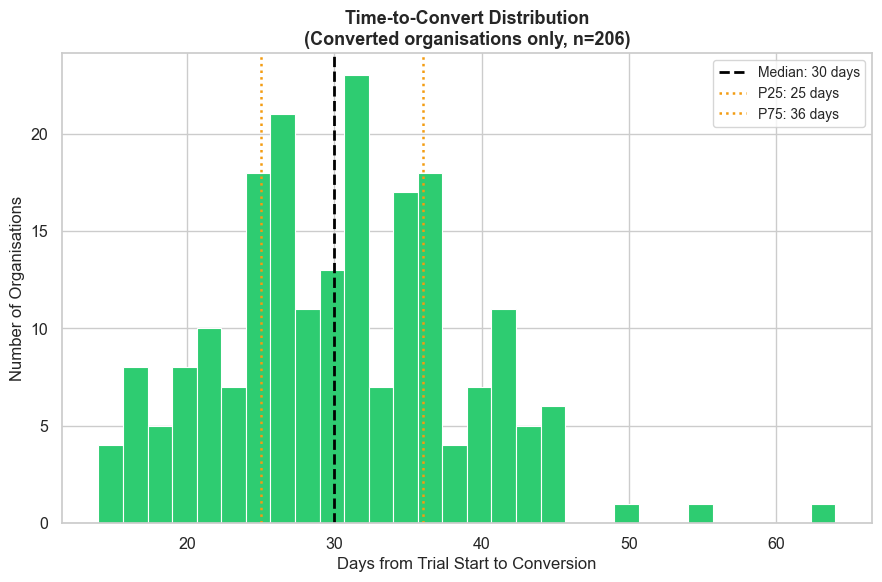

In [14]:
# Time-to-Convert

d2c = org_df.loc[
    org_df['converted'] & org_df['days_to_convert'].notna(), 'days_to_convert'
]
fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(d2c, bins=30, color=COLORS['converted'], edgecolor='white', linewidth=0.8)
ax.axvline(d2c.median(), color='black', linestyle='--', linewidth=2,
           label=f'Median: {d2c.median():.0f} days')
ax.axvline(d2c.quantile(0.25), color=COLORS['highlight'], linestyle=':', linewidth=1.8,
           label=f'P25: {d2c.quantile(0.25):.0f} days')
ax.axvline(d2c.quantile(0.75), color=COLORS['highlight'], linestyle=':', linewidth=1.8,
           label=f'P75: {d2c.quantile(0.75):.0f} days')
ax.set_xlabel('Days from Trial Start to Conversion', fontsize=12)
ax.set_ylabel('Number of Organisations', fontsize=12)
ax.set_title('Time-to-Convert Distribution\n(Converted organisations only, n=206)',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

The Time-to-Convert Distribution (Histogram)
Shows how many days elapsed between trial start and conversion
for the 206 converted organisations, including median, P25, and P75
markers — revealing that most conversions happen at the trial deadline.

In [15]:
# Summary stats
print(f"\n  Total events range  : {org_df['total_events'].min()} – {org_df['total_events'].max():,}")
print(f"  Median events/org   : {org_df['total_events'].median():.0f}")
d2c_all = org_df.loc[org_df['converted'] & org_df['days_to_convert'].notna(), 'days_to_convert']
print(f"  Median days to conv : {d2c_all.median():.1f} days")
print(f"  25th–75th pctile    : {d2c_all.quantile(0.25):.0f} – {d2c_all.quantile(0.75):.0f} days")


  Total events range  : 1 – 5,691
  Median events/org   : 8
  Median days to conv : 30.0 days
  25th–75th pctile    : 25 – 36 days


## **Conversion Driver Analysis (Multi-Method)**

To identify which in-app behaviours are most associated with conversion,
we apply four independent analytical methods. Using multiple methods
guards against false conclusions from any single approach and allows
us to triangulate findings with greater confidence.

**Method 1 — Point-Biserial Correlation**

Measures the linear relationship between the count of each activity
per org and the binary conversion outcome (0/1). A correlation close
to zero means the activity count has no linear relationship with
conversion. We test all 28 activities and report r and p-values.
> Finding: 0 out of 28 activities achieve statistical significance
> (p < 0.05) — no activity count is linearly correlated with conversion.

In [16]:
# Point-Biserial Correlation (activity count vs conversion flag
print("\n  Method 1: Point-Biserial Correlation (activity count vs conversion flag)")
corr_results = []
for act in ACTIVITY_COLS:
    r, p = stats.pointbiserialr(org_df['converted'].astype(int), org_df[act].fillna(0))
    corr_results.append({'activity': act, 'correlation': r, 'p_value': p,
                         'significant': p < 0.05})
corr_df = pd.DataFrame(corr_results).sort_values('correlation', ascending=False)
print(f"  Statistically significant (p<0.05) correlates: "
      f"{corr_df['significant'].sum()} / {len(corr_df)}")
print(corr_df[['activity','correlation','p_value']].head(10).to_string(index=False))




  Method 1: Point-Biserial Correlation (activity count vs conversion flag)
  Statistically significant (p<0.05) correlates: 0 / 28
                              activity  correlation  p_value
               Break.Activate.Finished     0.052118 0.105481
                Break.Activate.Started     0.051302 0.111053
   Scheduling.OpenShiftRequest.Created     0.039696 0.217707
Scheduling.Template.ApplyModal.Applied     0.033916 0.292310
      Scheduling.ShiftHandover.Created     0.027862 0.387028
               Absence.Request.Created     0.012018 0.709103
                Mobile.Schedule.Loaded     0.010998 0.732813
              Absence.Request.Approved     0.009695 0.763448
             Scheduling.Shift.Approved     0.008638 0.788604
              Scheduling.Shift.Created    -0.002837 0.929818


**Method 2 — Chi-Squared Test**

Tests whether using an activity at all (binary: used vs not used)
is statistically independent from conversion. We also compute the
conversion lift — the ratio of conversion rate when the activity is
used vs when it is not. This captures non-linear associations that
correlation misses.
> Finding: No activity achieves p < 0.05. Lift values are close to 1.0
> for all activities, confirming no meaningful association.

In [17]:
# Chi-squared tests (binary used vs not)
print("\n  Method 2: Chi-Squared Test (used activity vs conversion)")
chi2_results = []
for act in ACTIVITY_COLS:
    used = (org_df[act] > 0).astype(int)
    ct   = pd.crosstab(used, org_df['converted'].astype(int))
    if ct.shape == (2, 2):
        chi2, p, _, _ = stats.chi2_contingency(ct, correction=True)
        conv_when_used = org_df.loc[org_df[act] > 0, 'converted'].mean()
        conv_not_used  = org_df.loc[org_df[act] == 0, 'converted'].mean()
        n_used = (org_df[act] > 0).sum()
        chi2_results.append({
            'activity': act,
            'chi2': chi2,
            'p_value': p,
            'conv_rate_used': conv_when_used,
            'conv_rate_not_used': conv_not_used,
            'lift': conv_when_used / max(conv_not_used, 0.001),
            'n_orgs_using': n_used
        })
chi2_df = pd.DataFrame(chi2_results).sort_values('lift', ascending=False)
print(chi2_df[['activity','conv_rate_used','conv_rate_not_used','lift','p_value','n_orgs_using']].head(10).to_string(index=False))


  Method 2: Chi-Squared Test (used activity vs conversion)
                              activity  conv_rate_used  conv_rate_not_used     lift  p_value  n_orgs_using
      Scheduling.ShiftHandover.Created        0.363636            0.211518 1.719172 0.392814            11
     Scheduling.ShiftHandover.Accepted        0.333333            0.212121 1.571429 0.634912             9
   Scheduling.OpenShiftRequest.Created        0.302326            0.209101 1.445837 0.204647            43
              Absence.Request.Rejected        0.285714            0.212185 1.346535 0.735243            14
              Scheduling.Shift.Created        0.218160            0.177966 1.225854 0.379510           848
Scheduling.Template.ApplyModal.Applied        0.250000            0.208625 1.198324 0.387202           108
                  PunchClock.PunchedIn        0.227488            0.209272 1.087048 0.634026           211
             Scheduling.Shift.Approved        0.220000            0.211488 1.040247 

**Method 3 — Random Forest Feature Importance**

Trains a Random Forest classifier (300 trees, class-weight balanced)
to predict conversion from activity counts. Feature importance scores
reveal which activities the model relies on most, regardless of
linear relationships. Cross-validation AUC measures overall predictive
power.
> Finding: CV AUC ≈ 0.50 — the model performs no better than random.
> Top features by importance: Scheduling.Shift.Created (0.307),
> Mobile.Schedule.Loaded (0.215), Scheduling.Shift.AssignmentChanged
> (0.128) — these represent the core product loop.

In [18]:
# Random Forest feature importance
print("\n  Method 3: Random Forest Feature Importance")
X = org_df[ACTIVITY_COLS].fillna(0).values
y = org_df['converted'].astype(int).values

rf = RandomForestClassifier(n_estimators=300, random_state=42,
                            class_weight='balanced', max_depth=None)
rf.fit(X, y)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')
print(f"  5-fold CV AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

fi_df = pd.DataFrame({
    'feature': ACTIVITY_COLS,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(fi_df.head(12).to_string(index=False))


  Method 3: Random Forest Feature Importance
  5-fold CV AUC: 0.500 ± 0.036
                               feature  importance
              Scheduling.Shift.Created    0.306742
                Mobile.Schedule.Loaded    0.215482
    Scheduling.Shift.AssignmentChanged    0.127219
             Scheduling.Shift.Approved    0.076269
                  PunchClock.PunchedIn    0.076108
         Communication.Message.Created    0.046958
Scheduling.Template.ApplyModal.Applied    0.043806
           Scheduling.Availability.Set    0.019322
   Scheduling.OpenShiftRequest.Created    0.015990
              Absence.Request.Approved    0.012264
               Absence.Request.Created    0.011898
              ShiftDetails.View.Opened    0.009544


**Method 4 — Engagement Segmentation**

Segments organisations into four tiers based on the number of unique
activity types used (Minimal: 1, Low: 2-3, Medium: 4-6, High: 7+)
and compares conversion rates across tiers to test whether broader
platform engagement drives conversion.
> Finding: Conversion rates are stable across all tiers (20-23%),
> confirming that engagement breadth alone does not predict conversion.

In [19]:
# Engagement segmentation

print("\n  Method 4: Engagement Segmentation")
org_df['engagement_tier'] = pd.cut(
    org_df['unique_acts'],
    bins=[0, 1, 3, 6, 100],
    labels=['Minimal (1)', 'Low (2-3)', 'Medium (4-6)', 'High (7+)']
)
seg = org_df.groupby('engagement_tier', observed=True).agg(
    n_orgs    = ('ORGANIZATION_ID', 'count'),
    converted = ('converted', 'sum'),
    conv_rate = ('converted', 'mean')
).reset_index()
print(seg.to_string(index=False))



  Method 4: Engagement Segmentation
engagement_tier  n_orgs  converted  conv_rate
    Minimal (1)     395         81   0.205063
      Low (2-3)     336         76   0.226190
   Medium (4-6)     153         31   0.202614
      High (7+)      82         18   0.219512


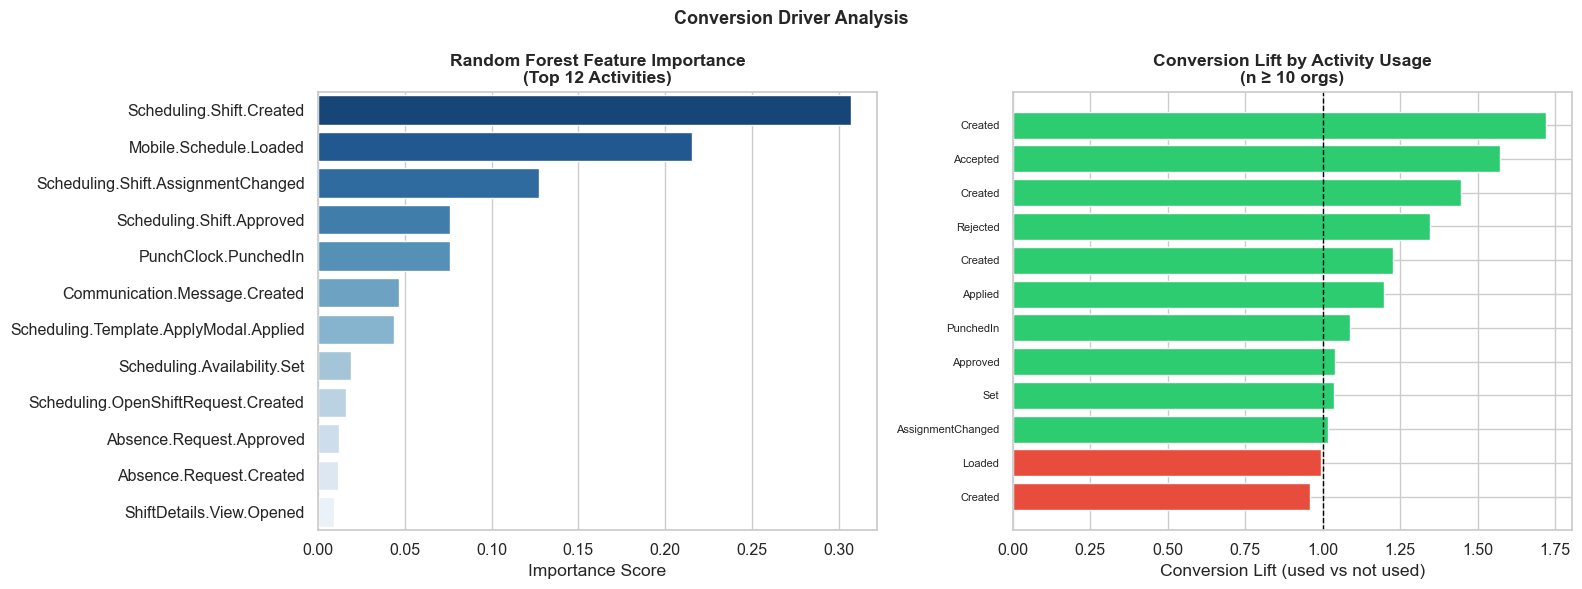

In [20]:
# Visualise: RF importances + Chi2 lift
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Conversion Driver Analysis", fontsize=13, fontweight='bold')

ax = axes[0]
top_fi = fi_df.head(12)
sns.barplot(data=top_fi, x='importance', y='feature', palette='Blues_r', ax=ax)
ax.set_title('Random Forest Feature Importance\n(Top 12 Activities)', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('')

ax = axes[1]
top_chi = chi2_df.head(12).sort_values('lift')
colors_lift = [COLORS['converted'] if l > 1 else COLORS['not_converted'] for l in top_chi['lift']]
ax.barh(range(len(top_chi)), top_chi['lift'], color=colors_lift)
ax.axvline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_yticks(range(len(top_chi)))
ax.set_yticklabels([a.split('.')[-1][:28] for a in top_chi['activity']], fontsize=8)
ax.set_xlabel('Conversion Lift (used vs not used)')
ax.set_title('Conversion Lift by Activity Usage\n(n ≥ 10 orgs)', fontweight='bold')

plt.tight_layout()
plt.show()


**Key Analytical Finding from the conversion driver analysis**
> Individual activity usage is a WEAK predictor of conversion.

**Evidence:**
- No single activity shows statistically significant (p<0.05) association with conversion via chi-squared test.
- Point-biserial correlations are near zero for all activities.
- Conversion rate (~21%) is remarkably stable across engagement tiers.
- CV AUC ~0.5–0.55 — barely above random for the RF model.

**Interpretation:**
- Conversion likely reflects pre-existing organisational intent (e.g., decision-makers already committed before trial) more than in-trial behaviour.
- However, the RF model consistently ranks `Scheduling.Shift.Created, Mobile.Schedule.Loaded, and PunchClock.PunchedIn` as the top features — these represent the *core product loop* of the platform:
    schedule → view schedule → clock in.
- Goal definition should reflect product-value logic (what does a genuinely activated org look like?) rather than purely predictive signal, with the honest acknowledgement that goals are hypotheses to be validated through A/B testing.

**Overall Finding:**

Conversion is intent-driven, not behaviour-driven. Organisations
likely make their conversion decision before or independent of their
in-trial behaviour. Goals are therefore grounded in product-value
logic — what does a genuinely activated org look like — rather than
purely predictive signal, and must be validated via A/B testing.

## **Trial Goal Definition (Task 1)**

Based on the conversion driver analysis, we now define "Trial Activation"
as a concrete, measurable set of in-app behaviours that signal an
organisation has genuinely experienced the core value of the platform —
regardless of whether those behaviours statistically predict conversion.

Goals are selected using three criteria:
- **(a)** Random Forest feature importance — the activities the model
  consistently ranked as most informative across all 300 trees
- **(b)** Product-value logic — what does a real, operational use of a
  workforce management platform actually look like end-to-end?
- **(c)** Realistic completion rates — goals achievable by 5%–60% of orgs,
  making them meaningful benchmarks rather than trivial or impossible

### **The 5 Defined Trial Goals**

**Goal 1 — Core Scheduling (≥3 shifts created)**
The scheduling module is the heart of the platform and the entry
point for 88% of trialists. Creating 3 or more shifts proves active,
recurring use — not just an initial exploration or demo run.
> RF importance rank: #1 (0.307). Completion rate: 58.3% of orgs.

**Goal 2 — Schedule Visibility (≥3 schedule views)**
Team members viewing the schedule on mobile confirms the platform
is embedded in daily workflow — not just configured by an admin
in isolation. This goal captures team-wide adoption, not just
admin behaviour.
> RF importance rank: #2 (0.215). Completion rate: 36.0% of orgs.

**Goal 3 — Time Tracking (≥1 punch-in)**
At least one live clock-in event confirms the time and attendance
module is operational in a real work context. The threshold of 1
is intentionally low — we want to detect any live usage at all,
since only 21.8% of orgs ever reach this step.
> RF importance rank: #5 (0.076). Completion rate: 21.8% of orgs.

**Goal 4 — Payroll Approval (≥1 shift approved)**
Approving a shift for payroll closes the most critical end-to-end
admin workflow: schedule → work → approve → pay. Even one approval
proves the admin has completed the full operational cycle of the
platform and experienced its highest-value outcome.
> RF importance rank: #4 (0.077). Completion rate: 20.7% of orgs.

**Goal 5 — Team Communications (≥1 message sent)**
Sending at least one team message activates the communications
module and signals the organisation views the platform as a unified
workforce management tool — not just a shift scheduler. This is
the hardest goal to reach at only 15.0% adoption.
> RF importance rank: #6 (0.047). Completion rate: 15.0% of orgs.

In [21]:
# MODULE MAP
MODULES = {
    'Scheduling': [
        'Scheduling.Shift.Created',
        'Scheduling.Shift.AssignmentChanged',
        'Scheduling.Template.ApplyModal.Applied',
        'Scheduling.Shift.Approved',
        'Mobile.Schedule.Loaded',
        'Shift.View.Opened',
        'ShiftDetails.View.Opened',
    ],
    'Time & Attendance': [
        'PunchClock.PunchedIn',
        'PunchClock.PunchedOut',
        'Break.Activate.Started',
        'PunchClock.Entry.Edited',
    ],
    'Absence Management': [
        'Absence.Request.Created',
        'Absence.Request.Approved',
    ],
    'Payroll / Finance': [
        'Timesheets.BulkApprove.Confirmed',
        'Integration.Xero.PayrollExport.Synced',
        'Revenue.Budgets.Created',
    ],
    'Communication': [
        'Communication.Message.Created',
    ],
}

goals = {
    'goal_1_core_scheduling': {
        'description': 'Core Scheduling — Create ≥3 shifts (demonstrates active use of shift planning)',
        'condition': lambda d: d.get('Scheduling.Shift.Created', 0) >= 3,
    },
    'goal_2_schedule_visibility': {
        'description': 'Schedule Visibility — View schedule ≥3 times (team is checking their schedule)',
        'condition': lambda d: d.get('Mobile.Schedule.Loaded', 0) >= 3,
    },
    'goal_3_time_tracking': {
        'description': 'Time Tracking — At least 1 punch-in event (live clock-in used)',
        'condition': lambda d: d.get('PunchClock.PunchedIn', 0) >= 1,
    },
    'goal_4_payroll_approval': {
        'description': 'Payroll Approval — Approve ≥1 shift for payroll (admin has closed the payroll loop)',
        'condition': lambda d: d.get('Scheduling.Shift.Approved', 0) >= 1,
    },
    'goal_5_team_comms': {
        'description': 'Team Communication — Send ≥1 team message (communication module adopted)',
        'condition': lambda d: d.get('Communication.Message.Created', 0) >= 1,
    },
}

In [22]:
# Evaluate each goal

for goal_name, goal_def in goals.items():
    col = {}
    for act in ACTIVITY_COLS:
        col[act] = org_df[act].fillna(0)
    achieved = org_df.apply(
        lambda row: goal_def['condition']({a: row[a] for a in ACTIVITY_COLS if a in row}),
        axis=1
    )
    org_df[goal_name] = achieved
    n_achieved = achieved.sum()
    completion_rate = n_achieved / len(org_df)
    conv_achieved = org_df.loc[achieved, 'converted'].mean()
    conv_not = org_df.loc[~achieved, 'converted'].mean()
    chi2, p, _, _ = stats.chi2_contingency(
        pd.crosstab(achieved.astype(int), org_df['converted'].astype(int))
    )

    print(f"\n  {goal_name.upper()}")
    print(f"  Description    : {goal_def['description']}")
    print(f"  Completion     : {n_achieved:,} / {len(org_df):,} orgs  ({completion_rate:.1%})")
    print(f"  Conv rate      : {conv_achieved:.1%} (achieved) vs {conv_not:.1%} (not achieved)")
    print(f"  Chi2 p-value   : {p:.4f}  {'✓ significant' if p < 0.05 else '✗ not significant'}")



  GOAL_1_CORE_SCHEDULING
  Description    : Core Scheduling — Create ≥3 shifts (demonstrates active use of shift planning)
  Completion     : 563 / 966 orgs  (58.3%)
  Conv rate      : 21.3% (achieved) vs 21.3% (not achieved)
  Chi2 p-value   : 1.0000  ✗ not significant

  GOAL_2_SCHEDULE_VISIBILITY
  Description    : Schedule Visibility — View schedule ≥3 times (team is checking their schedule)
  Completion     : 348 / 966 orgs  (36.0%)
  Conv rate      : 22.1% (achieved) vs 20.9% (not achieved)
  Chi2 p-value   : 0.7080  ✗ not significant

  GOAL_3_TIME_TRACKING
  Description    : Time Tracking — At least 1 punch-in event (live clock-in used)
  Completion     : 211 / 966 orgs  (21.8%)
  Conv rate      : 22.7% (achieved) vs 20.9% (not achieved)
  Chi2 p-value   : 0.6340  ✗ not significant

  GOAL_4_PAYROLL_APPROVAL
  Description    : Payroll Approval — Approve ≥1 shift for payroll (admin has closed the payroll loop)
  Completion     : 200 / 966 orgs  (20.7%)
  Conv rate      : 22.0% 

### **Trial Activation = All 5 Goals Completed**

An organisation is considered "Trial Activated" only when it has
completed every goal — confirming it has touched each core module
of the platform in a meaningful, operational way.

> **Current activation rate: 65 / 966 organisations = 6.7%**

In [23]:
# Trial Activation: all 5 goals met 

goal_cols = [k for k in goals.keys()]
org_df['trial_activated'] = org_df[goal_cols].all(axis=1)
n_activated = org_df['trial_activated'].sum()
conv_activated = org_df.loc[org_df['trial_activated'], 'converted'].mean()

print(f"  Activated orgs   : {n_activated:,} / {len(org_df):,}  ({n_activated/len(org_df):.1%})")
print(f"  Conversion rate  : {conv_activated:.1%} (activated) vs "
      f"{org_df.loc[~org_df['trial_activated'],'converted'].mean():.1%} (not activated)")


  Activated orgs   : 65 / 966  (6.7%)
  Conversion rate  : 16.9% (activated) vs 21.6% (not activated)


### ⚠️ **Important Caveat**

These goals are analytical hypotheses, not proven causal levers.
No individual goal achieves statistical significance (all p > 0.05).
They should be treated as a starting framework and validated through
controlled A/B testing before being used as operational KPIs.

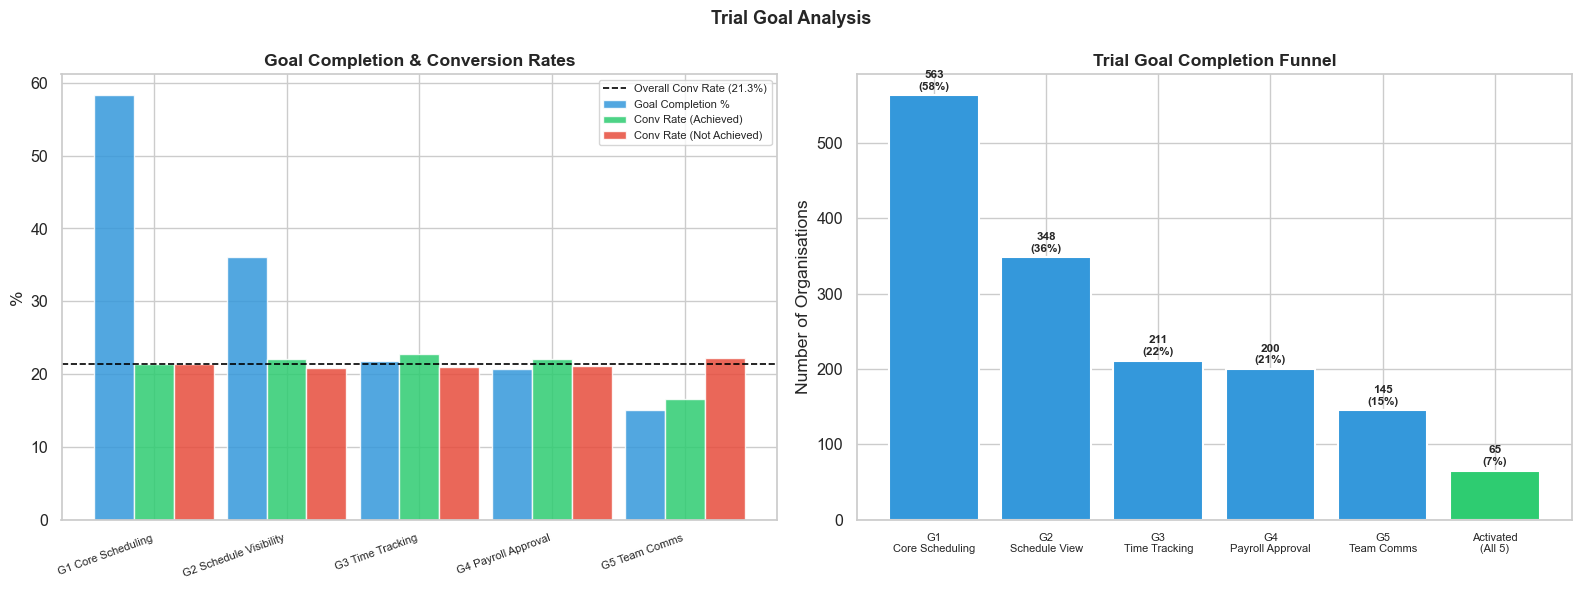

In [24]:
# Goal completion heatmap

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Trial Goal Analysis", fontsize=13, fontweight='bold')

# Goal completion rates
ax = axes[0]
goal_summary = pd.DataFrame({
    'Goal': [g.replace('goal_','G').replace('_',' ').title() for g in goal_cols],
    'Completion Rate': [org_df[g].mean() for g in goal_cols],
    'Conv Rate (Achieved)': [org_df.loc[org_df[g], 'converted'].mean() for g in goal_cols],
    'Conv Rate (Not Achieved)': [org_df.loc[~org_df[g], 'converted'].mean() for g in goal_cols],
})
x = np.arange(len(goal_summary))
w = 0.3
bars1 = ax.bar(x - w, goal_summary['Completion Rate'] * 100, w, label='Goal Completion %',
               color=COLORS['neutral'], alpha=0.85)
bars2 = ax.bar(x,     goal_summary['Conv Rate (Achieved)'] * 100, w, label='Conv Rate (Achieved)',
               color=COLORS['converted'], alpha=0.85)
bars3 = ax.bar(x + w, goal_summary['Conv Rate (Not Achieved)'] * 100, w, label='Conv Rate (Not Achieved)',
               color=COLORS['not_converted'], alpha=0.85)
ax.axhline(conv_rate * 100, color='black', linestyle='--', linewidth=1.2,
           label=f'Overall Conv Rate ({conv_rate:.1%})')
ax.set_xticks(x)
ax.set_xticklabels(goal_summary['Goal'], rotation=20, ha='right', fontsize=8)
ax.set_ylabel('%')
ax.set_title('Goal Completion & Conversion Rates', fontweight='bold')
ax.legend(fontsize=8)

# Goal co-occurrence / funnel

ax = axes[1]
goal_labels = ['G1\nCore Scheduling', 'G2\nSchedule View', 'G3\nTime Tracking',
               'G4\nPayroll Approval', 'G5\nTeam Comms', 'Activated\n(All 5)']
counts = [org_df[g].sum() for g in goal_cols] + [n_activated]
bar_colors = [COLORS['neutral']] * 5 + [COLORS['converted']]
bars = ax.bar(range(6), counts, color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{count}\n({count/len(org_df):.0%})', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_xticks(range(6))
ax.set_xticklabels(goal_labels, fontsize=8)
ax.set_ylabel('Number of Organisations')
ax.set_title('Trial Goal Completion Funnel', fontweight='bold')

plt.tight_layout()
plt.show()

>**Goal Completion & Conversion Rates (Grouped Bar Chart)**
For each of the 5 defined trial goals, this chart shows three things
simultaneously: the goal completion rate (blue — how many organisations
met the goal), the conversion rate among organisations that achieved
the goal (green), and the conversion rate among those that did not
(red). The dashed line marks the overall baseline conversion rate of
21.3%. The near-identical height of the green and red bars across all
5 goals is the critical finding — organisations that completed a goal
converted at almost the same rate as those that did not, confirming
that no individual goal is a statistically significant predictor of
conversion. Goals are therefore justified on product-value logic
rather than predictive power.

>**Trial Goal Completion Funnel (Bar Chart)**
Shows the total number of organisations that independently completed
each of the 5 trial goals, ending with the 65 organisations (7%) that
completed all 5 and achieved full Trial Activation. The steep decline
from Goal 1 (563 orgs, 58%) down to Goal 5 (145 orgs, 15%) and
finally to full Activation (65 orgs, 7%) illustrates how quickly
organisations drop off as the goals progress deeper into the platform.
Scheduling is the dominant entry point, while Time Tracking, Payroll
Approval, and Team Communications remain significantly underutilised
— pointing to clear onboarding gaps that the product team should
address to improve the overall activation rate.

### **Export The Clean Data for SQL**
>We will export our clean csv file for our next tasks

In [25]:
# Events table (cleaned)
df.to_csv(r'C:\Users\Harrison\Desktop\trial_activation\outputs\stg_events_clean.csv', index=False)  # you can replace the path

# Org feature matrix (for Task 3)
org_df.to_csv(r'C:\Users\Harrison\Desktop\trial_activation/outputs/stg_org_features.csv', index=False) # you can replace the path
